In [1]:
import pandas as pd
import numpy as np
from pyomo.environ import *
from pyomo.dae import *
import matplotlib.pyplot as plt

# 1. Carregar dados
file_name = 'dados2.xlsx'
df = pd.read_excel(file_name)

# Colunas da planilha
lumps = ['Hn', 'Hiso', 'Dn', 'Diso', 'Qn', 'Qiso', 'Nn', 'Niso', 'G']

# Normalização: soma de cada linha = 1.0
df[lumps] = df[lumps].div(df[lumps].sum(axis=1), axis=0)

t_exp = df['x'].values
dados_exp = {lump: df[lump].values for lump in lumps}
val_iniciais = {lump: dados_exp[lump][0] for lump in lumps}

# 2. Modelo Pyomo para Estimação
def solve_estimation(temp_celsius):
    m = ConcreteModel()
    R = 8.314 / 1000  # kJ/mol.K
    T = temp_celsius + 273.15

    m.t = ContinuousSet(initialize=t_exp)
    m.lump = Set(initialize=lumps)

    # 10 parâmetros cinéticos
    m.lnA = Var(RangeSet(1, 10), initialize=15.0, bounds=(5, 50))
    m.Ea = Var(RangeSet(1, 10), initialize=80.0, bounds=(30, 250))

    m.C = Var(m.lump, m.t, within=NonNegativeReals)
    m.dCdt = DerivativeVar(m.C, wrt=m.t)

    def _k(m, i):
        return exp(m.lnA[i] - m.Ea[i] / (R * T))

    def _balanco(m, l, t):
        if l == 'Hn':
            return m.dCdt[l, t] == -_k(m, 1)*m.C['Hn', t] + _k(m, 2)*m.C['Hiso', t] - _k(m, 5)*m.C['Hn', t]

        elif l == 'Hiso':
            return m.dCdt[l, t] == _k(m, 1)*m.C['Hn', t] - _k(m, 2)*m.C['Hiso', t] - _k(m, 3)*m.C['Hiso', t] + _k(m, 4)*m.C['Dn', t] + _k(m, 5)*m.C['Hn', t] - _k(m, 6)*m.C['Hiso', t]

        elif l == 'Dn':
            return m.dCdt[l, t] == _k(m, 3)*m.C['Hiso', t] - _k(m, 4)*m.C['Dn', t] - _k(m, 7)*m.C['Dn', t] + _k(m, 8)*m.C['Diso', t]

        elif l == 'Diso':
            return m.dCdt[l, t] == _k(m, 7)*m.C['Dn', t] - _k(m, 8)*m.C['Diso', t] - _k(m, 9)*m.C['Diso', t] + _k(m, 10)*m.C['Qn', t]

        elif l == 'Qn':
            return m.dCdt[l, t] == _k(m, 9)*m.C['Diso', t] - _k(m, 10)*m.C['Qn', t] - _k(m, 1)*m.C['Qn', t] + _k(m, 2)*m.C['Qiso', t]

        elif l == 'Qiso':
            return m.dCdt[l, t] == _k(m, 1)*m.C['Qn', t] - _k(m, 2)*m.C['Qiso', t] - _k(m, 3)*m.C['Qiso', t] + _k(m, 4)*m.C['Nn', t]

        elif l == 'Nn':
            return m.dCdt[l, t] == _k(m, 3)*m.C['Qiso', t] - _k(m, 4)*m.C['Nn', t] - _k(m, 5)*m.C['Nn', t] + _k(m, 6)*m.C['Niso', t]

        elif l == 'Niso':
            return m.dCdt[l, t] == _k(m, 5)*m.C['Nn', t] - _k(m, 6)*m.C['Niso', t] - _k(m, 7)*m.C['Niso', t] + _k(m, 8)*m.C['G', t]

        elif l == 'G':
            return m.dCdt[l, t] == _k(m, 7)*m.C['Niso', t] - _k(m, 8)*m.C['G', t]

    m.ode = Constraint(m.lump, m.t, rule=_balanco)

    # Condições iniciais
    t0 = t_exp[0]
    for l in lumps:
        m.C[l, t0].fix(val_iniciais[l])

    def _obj(m):
        return sum(
            (m.C[l, t] - dados_exp[l][np.where(t_exp == t)[0][0]])**2
            for l in lumps for t in t_exp
        )

    m.obj = Objective(rule=_obj, sense=minimize)

    TransformationFactory('dae.collocation').apply_to(m, nfe=20, ncp=3)

    solver = SolverFactory('ipopt', executable=r'C:\ipopt\ipopt.exe')
    results = solver.solve(m, tee=True)

    return m

# 3. Execução
temp_exp = 400
model = solve_estimation(temp_exp)

if model is None:
    raise ValueError("solve_estimation não retornou um modelo válido.")

y_exp_all = []
y_model_all = []

for l in lumps:
    for i, t in enumerate(t_exp):
        y_exp_all.append(dados_exp[l][i])
        y_model_all.append(value(model.C[l, t]))

y_exp_all = np.array(y_exp_all)
y_model_all = np.array(y_model_all)

rmse = np.sqrt(np.mean((y_exp_all - y_model_all)**2))
print(f"\nRMSE global = {rmse:.5f}")

# 4. Resultados
print("--- Parâmetros Otimizados ---")
results_params = []
for i in range(1, 11):
    A = np.exp(value(model.lnA[i]))
    Ea = value(model.Ea[i])
    results_params.append({'Reacao': i, 'A': A, 'Ea': Ea})
    print(f"Reação {i}: A = {A:.2e} h⁻¹, Ea = {Ea:.2f} kJ/mol")

pd.DataFrame(results_params).to_csv('parametros_otimizados.csv', index=False)

# 5. Plotagem
plt.figure(figsize=(11, 6))
t_plot = sorted(list(model.t))

estilos = {
    'Hn': ('blue', 'o', '-'),
    'Hiso': ('cyan', 's', '--'),
    'Dn': ('red', '^', '-'),
    'Diso': ('orange', 'v', '--'),
    'Qn': ('purple', 'D', '-'),
    'Qiso': ('magenta', 'P', '--'),
    'Nn': ('green', 'd', '-'),
    'Niso': ('lime', 'x', '--'),
    'G': ('black', '*', '-.')
}

for l in lumps:
    color, marker, ls = estilos[l]
    plt.scatter(t_exp, dados_exp[l], color=color, marker=marker, alpha=0.5, label=f'{l} Exp')
    plt.plot(
        t_plot,
        [value(model.C[l, t]) for t in t_plot],
        color=color,
        linestyle=ls,
        label=f'{l} Modelo',
        linewidth=2
    )

plt.title(f"Ajuste Cinético Otimizado @ {temp_exp}°C")
plt.xlabel("Tempo (1/WHSV)")
plt.ylabel("Fração Mássica")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.text(
    0.80,
    0.05,
    f'RMSE = {rmse:.4f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.savefig('modelo_simplificado.png', dpi=300, bbox_inches='tight')
plt.show()

for solver ipopt. File with name=C:\ipopt\ipopt.exe either does not exist or
it is not executable. To skip this validation, call set_executable with
validate=False.
Traceback (most recent call last):
  File "C:\Users\giovani25025\AppData\Roaming\Python\Python312\site-packages\pyomo\opt\base\solvers.py", line 164, in __call__
    opt = self._cls[_name](**kwds)
          ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\giovani25025\AppData\Roaming\Python\Python312\site-packages\pyomo\solvers\plugins\solvers\IPOPT.py", line 42, in __init__
    super(IPOPT, self).__init__(**kwds)
  File "C:\Users\giovani25025\AppData\Roaming\Python\Python312\site-packages\pyomo\opt\solver\shellcmd.py", line 64, in __init__
    self.set_executable(name=executable, validate=validate)
  File "C:\Users\giovani25025\AppData\Roaming\Python\Python312\site-packages\pyomo\opt\solver\shellcmd.py", line 113, in set_executable
    raise ValueError(
ValueError: Failed to set executable for solver ipopt. File with name=C:\ipop

RuntimeError: Attempting to use an unavailable solver.

The SolverFactory was unable to create the solver "ipopt"
and returned an UnknownSolver object.  This error is raised at the point
where the UnknownSolver object was used as if it were valid (by calling
method "solve").

The original solver was created with the following parameters:
	executable: C:\ipopt\ipopt.exe
	type: ipopt
	_args: ()
	options: {}

In [2]:
print(df.columns.tolist())

['x', 'Hn', 'Hiso', 'Dn', 'Diso', 'Qn', 'Qiso', 'Nn', 'Niso', 'G']


Ipopt 3.12.13: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

This is Ipopt version 3.12.13, running with linear solver mumps.
NOTE: Other linear solvers might be more efficient (see Ipopt documentation).

Number of nonzeros in equality constraint Jacobian...:     8954
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     2280

Total number of variables............................:     1109
                     variables with only lower bounds:      540
                variables with lower and upper bounds:       20
                     variables with only upper bounds:        0
Tot

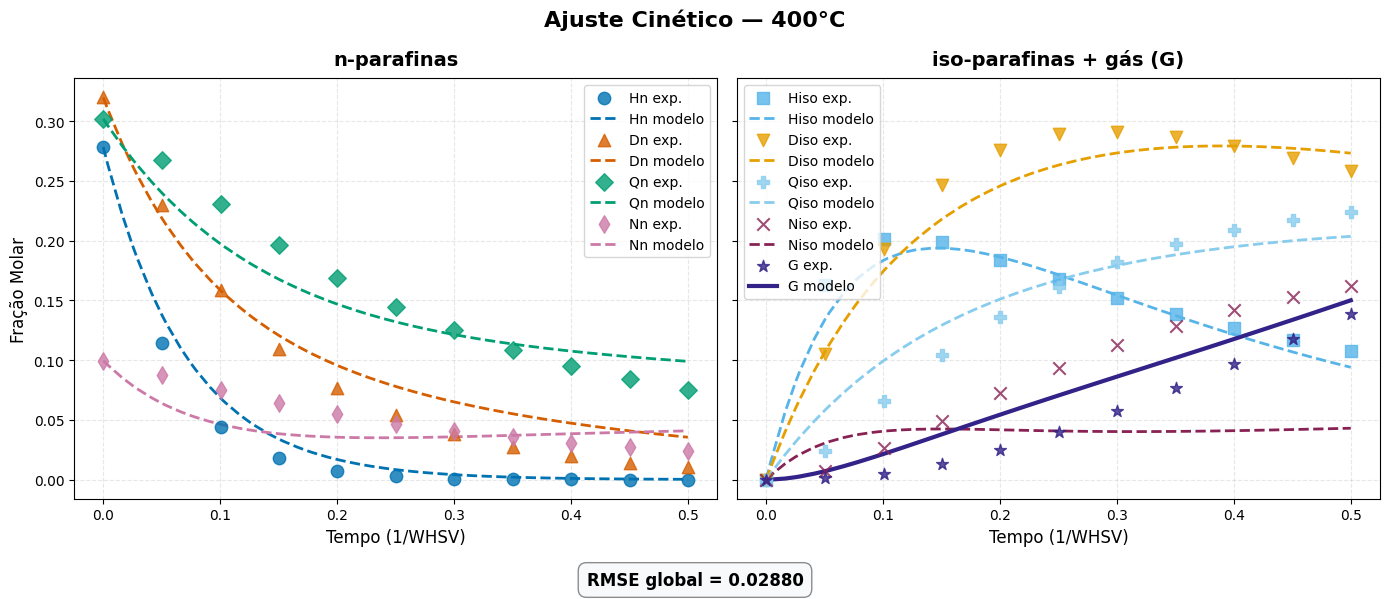

In [2]:
import pandas as pd
import numpy as np
from pyomo.environ import *
from pyomo.dae import *
import matplotlib.pyplot as plt

# 1. CARREGAMENTO E NORMALIZAÇÃO DOS DADOS
file_name = 'dados2.xlsx'
df = pd.read_excel(file_name)

# Separação explícita entre n-parafinas, iso-parafinas e produto final
lumps_n   = ['Hn', 'Dn', 'Qn', 'Nn']          # n-parafinas (cadeia normal)
lumps_iso = ['Hiso', 'Diso', 'Qiso', 'Niso']   # iso-parafinas (ramificadas)
lumps_G   = ['G']                               # produto final (gás/coque)
lumps     = lumps_n + lumps_iso + lumps_G       # ordem completa

# Normalização: cada linha deve somar 1.0 (fração mássica)
df[lumps] = df[lumps].div(df[lumps].sum(axis=1), axis=0)

t_exp       = df['x'].values                            # vetor de tempos (1/WHSV)
dados_exp   = {lump: df[lump].values for lump in lumps} # dicionário espécie → array
val_iniciais = {lump: dados_exp[lump][0] for lump in lumps} # condições iniciais

# 2. MODELO PYOMO PARA ESTIMAÇÃO DE PARÂMETROS
def solve_estimation(temp_celsius):
    m = ConcreteModel()
    R = 8.314 / 1000   # constante dos gases [kJ/(mol·K)]
    T = temp_celsius + 273.15  # temperatura absoluta [K]

    # Conjuntos 
    m.t    = ContinuousSet(initialize=t_exp)   # domínio temporal (pontos experimentais)
    m.lump = Set(initialize=lumps)             # conjunto de espécies

    # Parâmetros cinéticos (variáveis de decisão) 
    m.lnA = Var(RangeSet(1, 10), initialize=15.0, bounds=(5, 50))
    m.Ea  = Var(RangeSet(1, 10), initialize=80.0, bounds=(30, 250))

    # Variáveis de estado: concentrações (frações mássicas) 
    m.C    = Var(m.lump, m.t, within=NonNegativeReals)
    m.dCdt = DerivativeVar(m.C, wrt=m.t)

    # Função auxiliar para calcular k[i]
    def _k(m, i):
        return exp(m.lnA[i] - m.Ea[i] / (R * T))
    
    # BALANÇOS DE MASSA (EDOs)
    def _balanco(m, l, t):
        k = lambda i: _k(m, i)   # atalho local

        # n-parafinas
        if l == 'Hn':
            return m.dCdt[l, t] == (
                - k(1)*m.C['Hn',   t]      
                + k(2)*m.C['Hiso', t]      
                - k(5)*m.C['Hn',   t]      
            )
        elif l == 'Dn':
            return m.dCdt[l, t] == (
                + k(3)*m.C['Hiso', t]      
                - k(4)*m.C['Dn',   t]      
                - k(7)*m.C['Dn',   t]      
                + k(8)*m.C['Diso', t]      
            )
        elif l == 'Qn':
            return m.dCdt[l, t] == (
                + k(9) *m.C['Diso', t]     
                - k(10)*m.C['Qn',   t]     
                - k(1) *m.C['Qn',   t]     
                + k(2) *m.C['Qiso', t]     
            )
        elif l == 'Nn':
            return m.dCdt[l, t] == (
                + k(3)*m.C['Qiso', t]      
                - k(4)*m.C['Nn',   t]      
                - k(5)*m.C['Nn',   t]      
                + k(6)*m.C['Niso', t]      
            )

        # iso-parafinas 
        elif l == 'Hiso':
            return m.dCdt[l, t] == (
                + k(1)*m.C['Hn',   t]      
                - k(2)*m.C['Hiso', t]      
                - k(3)*m.C['Hiso', t]      
                + k(4)*m.C['Dn',   t]      
                + k(5)*m.C['Hn',   t]      
                - k(6)*m.C['Hiso', t]      
            )
        elif l == 'Diso':
            return m.dCdt[l, t] == (
                + k(7) *m.C['Dn',   t]     
                - k(8) *m.C['Diso', t]     
                - k(9) *m.C['Diso', t]     
                + k(10)*m.C['Qn',   t]     
            )
        elif l == 'Qiso':
            return m.dCdt[l, t] == (
                + k(1)*m.C['Qn',   t]      
                - k(2)*m.C['Qiso', t]      
                - k(3)*m.C['Qiso', t]      
                + k(4)*m.C['Nn',   t]      
            )
        elif l == 'Niso':
            return m.dCdt[l, t] == (
                + k(5)*m.C['Nn',   t]      
                - k(6)*m.C['Niso', t]      
                - k(7)*m.C['Niso', t]      
                + k(8)*m.C['G',    t]      
            )

        # produto final
        elif l == 'G':
            return m.dCdt[l, t] == (
                + k(7)*m.C['Niso', t]      
                - k(8)*m.C['G',    t]      
            )

    m.ode = Constraint(m.lump, m.t, rule=_balanco)

    # Condições iniciais
    t0 = t_exp[0]
    for l in lumps:
        m.C[l, t0].fix(val_iniciais[l])

    # Função objetivo
    def _obj(m):
        erro_acumulado = 0
        for l in lumps:
            for t in t_exp:
                idx = np.where(t_exp == t)[0][0]
                real = dados_exp[l][idx]
                previsto = m.C[l, t]
                erro_acumulado += ((previsto - real))**2
        return erro_acumulado

    m.obj = Objective(rule=_obj, sense=minimize)

    # Discretização
    TransformationFactory('dae.collocation').apply_to(m, nfe=20, ncp=3)

    # Solver
    solver = SolverFactory('ipopt', executable=r'C:\zebra\ipopt.exe')
    results = solver.solve(m, tee=True)

    return m

# 3. EXECUÇÃO E CÁLCULO DO RMSE
temp_exp = 400
model = solve_estimation(temp_exp)

if model is None:
    raise ValueError("solve_estimation não retornou um modelo válido.")

rmse_por_especie = {}
for l in lumps:
    y_exp   = np.array([dados_exp[l][i] for i, _ in enumerate(t_exp)])
    y_model = np.array([value(model.C[l, t]) for t in t_exp])
    rmse_por_especie[l] = np.sqrt(np.mean((y_exp - y_model) ** 2))

y_exp_all   = np.concatenate([dados_exp[l]                      for l in lumps])
y_model_all = np.concatenate([[value(model.C[l, t]) for t in t_exp] for l in lumps])
rmse_global = np.sqrt(np.mean((y_exp_all - y_model_all) ** 2))

print()
print("RMSE POR ESPÉCIE")
print()
print("\n n-parafinas")
for l in lumps_n:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print("\n iso-parafinas")
for l in lumps_iso:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print("\n Produto final")
for l in lumps_G:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print(f"\n{'RMSE global':<12}: {rmse_global:.5f}")
print()

# 4. PARÂMETROS OTIMIZADOS
print("\n Parâmetros Otimizados")
results_params = []
for i in range(1, 11):
    A  = np.exp(value(model.lnA[i]))
    Ea = value(model.Ea[i])
    results_params.append({'Reacao': i, 'A (h⁻¹)': A, 'Ea (kJ/mol)': Ea})
    print(f"  Reação {i:>2}: A = {A:.2e} h⁻¹,  Ea = {Ea:.2f} kJ/mol")

pd.DataFrame(results_params).to_csv('parametros_otimizados.csv', index=False)

rmse_df = pd.DataFrame([
    {'Especie': l, 'Grupo': 'n-parafina' if l in lumps_n else ('iso-parafina' if l in lumps_iso else 'produto'),
     'RMSE': rmse_por_especie[l]}
    for l in lumps
])
rmse_df.to_csv('rmse_por_especie.csv', index=False)

# =============================================================================
# 5. PLOTAGEM — n-parafinas vs (iso-parafinas + G)
# =============================================================================
t_plot = sorted(list(model.t))

# Dicionários únicos de Cores e Marcadores (Okabe-Ito + Paul Tol vibrante)
cores = {
    'Hn': '#0072B2',    # Azul Forte
    'Dn': '#D55E00',    # Vermelho
    'Qn': '#009E73',    # Verde-azulado
    'Nn': '#CC79A7',    # Púrpura/Rosa
    'Hiso': '#56B4E9',  # Azul Claro
    'Diso': '#E69F00',  # Laranja
    'Qiso': '#88CCEE',  # Ciano 
    'Niso': '#882255',  # Vinho 
    'G': '#332288'      # Roxo Forte 
}

markers = {
    'Hn': 'o',  'Dn': '^',  'Qn': 'D',  'Nn': 'd',
    'Hiso': 's', 'Diso': 'v', 'Qiso': 'P', 'Niso': 'x',
    'G': '*'
}

# Criando figura com 2 subplots (n-parafinas na esquerda, iso + G na direita)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # Ajustei o tamanho para ficar bem distribuído
fig.suptitle(f"Ajuste Cinético — {temp_exp}°C", fontsize=16, fontweight='bold')

# Função auxiliar para plotar
def plotar_grupo(ax, especies, cores_dict, markers_dict, titulo):
    for l in especies:
        c  = cores_dict[l]
        mk = markers_dict[l]
        # Adicionei s=80 para os pontos ficarem visíveis e zorder=3 para ficarem sobre a linha
        ax.scatter(t_exp, dados_exp[l], color=c, marker=mk, s=80, alpha=0.8, zorder=3,
                   label=f'{l} exp.')
        
        # Linha contínua pro Gás, tracejada pros outros (opcional, mas ajuda a destacar o G)
        ls = '-' if l == 'G' else '--'
        lw = 3.0 if l == 'G' else 2.0
        
        ax.plot(t_plot, [value(model.C[l, t]) for t in t_plot],
                color=c, linewidth=lw, linestyle=ls, zorder=2,
                label=f'{l} modelo')
        
    ax.set_title(titulo, fontweight='bold', fontsize=14, pad=10)
    ax.set_xlabel("Tempo (1/WHSV)", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, loc='best')

# Plotando os grupos
plotar_grupo(axes[0], lumps_n, cores, markers, "n-parafinas")

# Somando as listas para que o Produto G apareça junto com as iso-parafinas
plotar_grupo(axes[1], lumps_iso + lumps_G, cores, markers, "iso-parafinas + gás (G)")

axes[0].set_ylabel("Fração Molar", fontsize=12)

# Caixa de RMSE global no canto inferior central
fig.text(0.5, 0.02, f'RMSE global = {rmse_global:.5f}',
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='gray'))

# Ajuste do layout para acomodar o texto na base
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('modelo_refatorado_acessivel.png', dpi=1200, bbox_inches='tight')
plt.show()

Ipopt 3.12.13: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt
******************************************************************************

This is Ipopt version 3.12.13, running with linear solver mumps.
NOTE: Other linear solvers might be more efficient (see Ipopt documentation).

Number of nonzeros in equality constraint Jacobian...:     7918
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     1812

Total number of variables............................:     1117
                     variables with only lower bounds:      540
                variables with lower and upper bounds:       28
                     variables with only upper bounds:        0
Tot

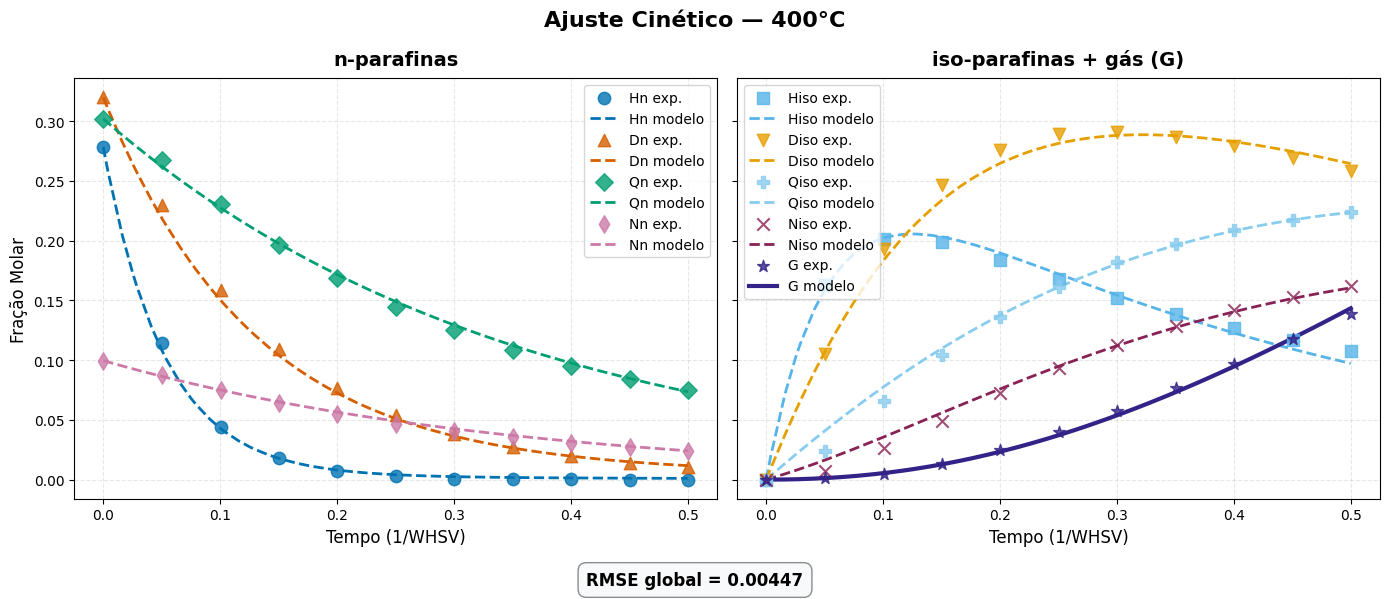

In [8]:
import pandas as pd
import numpy as np
from pyomo.environ import *
from pyomo.dae import *
import matplotlib.pyplot as plt

# 1. CARREGAMENTO E NORMALIZAÇÃO DOS DADOS
file_name = 'dados2.xlsx'
df = pd.read_excel(file_name)

# Separação explícita entre n-parafinas, iso-parafinas e produto final
lumps_n   = ['Hn', 'Dn', 'Qn', 'Nn']          # n-parafinas (cadeia normal)
lumps_iso = ['Hiso', 'Diso', 'Qiso', 'Niso']   # iso-parafinas (ramificadas)
lumps_G   = ['G']                               # produto final (gás/coque)
lumps     = lumps_n + lumps_iso + lumps_G       # ordem completa

# Normalização: cada linha deve somar 1.0 (fração mássica)
df[lumps] = df[lumps].div(df[lumps].sum(axis=1), axis=0)

t_exp       = df['x'].values                            # vetor de tempos (1/WHSV)
dados_exp   = {lump: df[lump].values for lump in lumps} # dicionário espécie → array
val_iniciais = {lump: dados_exp[lump][0] for lump in lumps} # condições iniciais

# 2. MODELO PYOMO PARA ESTIMAÇÃO DE PARÂMETROS
def solve_estimation(temp_celsius):
    m = ConcreteModel()
    R = 8.314 / 1000   # constante dos gases [kJ/(mol·K)]
    T = temp_celsius + 273.15  # temperatura absoluta [K]

    # Conjuntos 
    m.t    = ContinuousSet(initialize=t_exp)   # domínio temporal (pontos experimentais)
    m.lump = Set(initialize=lumps)             # conjunto de espécies

    # Parâmetros cinéticos (variáveis de decisão) 
    m.lnA = Var(RangeSet(1, 14), initialize=15.0, bounds=(5, 50))
    m.Ea  = Var(RangeSet(1, 14), initialize=80.0, bounds=(30, 250))

    # Variáveis de estado: concentrações (frações mássicas) 
    m.C    = Var(m.lump, m.t, within=NonNegativeReals)
    m.dCdt = DerivativeVar(m.C, wrt=m.t)

    # Função auxiliar para calcular k[i]
    def _k(m, i):
        return exp(m.lnA[i] - m.Ea[i] / (R * T))
    
    # BALANÇOS DE MASSA (EDOs)
    def _balanco(m, l, t):
        k = lambda i: _k(m, i)

        # ----- GRUPO H (Pesados, C22+) -----
        if l == 'Hn':
            return m.dCdt[l, t] == -k(1)*m.C['Hn', t] + k(2)*m.C['Hiso', t]
        
        elif l == 'Hiso':
            # Perde massa para Diso (k9) e diretamente para Qiso (k13 / mu5*)
            return m.dCdt[l, t] == k(1)*m.C['Hn', t] - k(2)*m.C['Hiso', t] - k(9)*m.C['Hiso', t] - k(13)*m.C['Hiso', t]

        # ----- GRUPO D (Diesel, C15-22) -----
        elif l == 'Dn':
            return m.dCdt[l, t] == -k(3)*m.C['Dn', t] + k(4)*m.C['Diso', t]
        
        elif l == 'Diso':
            # Perde massa para Qiso (k10) e diretamente para Niso (k14 / mu6)
            return m.dCdt[l, t] == (k(3)*m.C['Dn', t] - k(4)*m.C['Diso', t] 
                                    + k(9)*m.C['Hiso', t] - k(10)*m.C['Diso', t] - k(14)*m.C['Diso', t])

        # ----- GRUPO Q (Querosene, C10-14) -----
        elif l == 'Qn':
            return m.dCdt[l, t] == -k(5)*m.C['Qn', t] + k(6)*m.C['Qiso', t]
        
        elif l == 'Qiso':
            # Recebe de Diso (k10) e do salto de Hiso (k13 / mu5*)
            return m.dCdt[l, t] == (k(5)*m.C['Qn', t] - k(6)*m.C['Qiso', t] 
                                    + k(10)*m.C['Diso', t] - k(11)*m.C['Qiso', t] + k(13)*m.C['Hiso', t])

        # ----- GRUPO N (Nafta, C5-9) -----
        elif l == 'Nn':
            return m.dCdt[l, t] == -k(7)*m.C['Nn', t] + k(8)*m.C['Niso', t]
        
        elif l == 'Niso':
            # Recebe de Qiso (k11) e do salto de Diso (k14 / mu6)
            return m.dCdt[l, t] == (k(7)*m.C['Nn', t] - k(8)*m.C['Niso', t] 
                                    + k(11)*m.C['Qiso', t] - k(12)*m.C['Niso', t] + k(14)*m.C['Diso', t])

        # ----- PRODUTO GÁS (Leves, C1-4) -----
        elif l == 'G':
            return m.dCdt[l, t] == k(12)*m.C['Niso', t]

    m.ode = Constraint(m.lump, m.t, rule=_balanco)

    # Condições iniciais
    t0 = t_exp[0]
    for l in lumps:
        m.C[l, t0].fix(val_iniciais[l])

    # Função objetivo
    def _obj(m):
        erro_acumulado = 0
        for l in lumps:
            for t in t_exp:
                idx = np.where(t_exp == t)[0][0]
                real = dados_exp[l][idx]
                previsto = m.C[l, t]
                erro_acumulado += ((previsto - real))**2
        return erro_acumulado

    m.obj = Objective(rule=_obj, sense=minimize)

    # Discretização
    TransformationFactory('dae.collocation').apply_to(m, nfe=20, ncp=3)

    # Solver
    solver = SolverFactory('ipopt', executable=r'C:\zebra\ipopt.exe')
    results = solver.solve(m, tee=True)

    return m

# 3. EXECUÇÃO E CÁLCULO DO RMSE
temp_exp = 400
model = solve_estimation(temp_exp)

if model is None:
    raise ValueError("solve_estimation não retornou um modelo válido.")

rmse_por_especie = {}
for l in lumps:
    y_exp   = np.array([dados_exp[l][i] for i, _ in enumerate(t_exp)])
    y_model = np.array([value(model.C[l, t]) for t in t_exp])
    rmse_por_especie[l] = np.sqrt(np.mean((y_exp - y_model) ** 2))

y_exp_all   = np.concatenate([dados_exp[l]                      for l in lumps])
y_model_all = np.concatenate([[value(model.C[l, t]) for t in t_exp] for l in lumps])
rmse_global = np.sqrt(np.mean((y_exp_all - y_model_all) ** 2))

print()
print("RMSE POR ESPÉCIE")
print()
print("\n n-parafinas")
for l in lumps_n:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print("\n iso-parafinas")
for l in lumps_iso:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print("\n Produto final")
for l in lumps_G:
    print(f"  {l:<6}: {rmse_por_especie[l]:.5f}")

print(f"\n{'RMSE global':<12}: {rmse_global:.5f}")
print()

# 4. PARÂMETROS OTIMIZADOS
print("\n Parâmetros Otimizados")
results_params = []
for i in range(1, 15):
    A  = np.exp(value(model.lnA[i]))
    Ea = value(model.Ea[i])
    results_params.append({'Reacao': i, 'k_0 (h⁻¹)': A, 'Ea (kJ/mol)': Ea})
    print(f"  Reação {i:>2}: k_0 = {A:.2e} h⁻¹,  Ea = {Ea:.2f} kJ/mol")

pd.DataFrame(results_params).to_csv('parametros_otimizados.csv', index=False)

rmse_df = pd.DataFrame([
    {'Especie': l, 'Grupo': 'n-parafina' if l in lumps_n else ('iso-parafina' if l in lumps_iso else 'produto'),
     'RMSE': rmse_por_especie[l]}
    for l in lumps
])
rmse_df.to_csv('rmse_por_especie.csv', index=False)

# =============================================================================
# 5. PLOTAGEM — n-parafinas vs (iso-parafinas + G)
# =============================================================================
t_plot = sorted(list(model.t))

# Dicionários únicos de Cores e Marcadores (Okabe-Ito + Paul Tol vibrante)
cores = {
    'Hn': '#0072B2',    # Azul Forte
    'Dn': '#D55E00',    # Vermelho
    'Qn': '#009E73',    # Verde-azulado
    'Nn': '#CC79A7',    # Púrpura/Rosa
    'Hiso': '#56B4E9',  # Azul Claro
    'Diso': '#E69F00',  # Laranja
    'Qiso': '#88CCEE',  # Ciano 
    'Niso': '#882255',  # Vinho 
    'G': '#332288'      # Roxo Forte 
}

markers = {
    'Hn': 'o',  'Dn': '^',  'Qn': 'D',  'Nn': 'd',
    'Hiso': 's', 'Diso': 'v', 'Qiso': 'P', 'Niso': 'x',
    'G': '*'
}

# Criando figura com 2 subplots (n-parafinas na esquerda, iso + G na direita)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # Ajustei o tamanho para ficar bem distribuído
fig.suptitle(f"Ajuste Cinético — {temp_exp}°C", fontsize=16, fontweight='bold')

# Função auxiliar para plotar
def plotar_grupo(ax, especies, cores_dict, markers_dict, titulo):
    for l in especies:
        c  = cores_dict[l]
        mk = markers_dict[l]
        # Adicionei s=80 para os pontos ficarem visíveis e zorder=3 para ficarem sobre a linha
        ax.scatter(t_exp, dados_exp[l], color=c, marker=mk, s=80, alpha=0.8, zorder=3,
                   label=f'{l} exp.')
        
        # Linha contínua pro Gás, tracejada pros outros (opcional, mas ajuda a destacar o G)
        ls = '-' if l == 'G' else '--'
        lw = 3.0 if l == 'G' else 2.0
        
        ax.plot(t_plot, [value(model.C[l, t]) for t in t_plot],
                color=c, linewidth=lw, linestyle=ls, zorder=2,
                label=f'{l} modelo')
        
    ax.set_title(titulo, fontweight='bold', fontsize=14, pad=10)
    ax.set_xlabel("Tempo (1/WHSV)", fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, loc='best')

# Plotando os grupos
plotar_grupo(axes[0], lumps_n, cores, markers, "n-parafinas")

# Somando as listas para que o Produto G apareça junto com as iso-parafinas
plotar_grupo(axes[1], lumps_iso + lumps_G, cores, markers, "iso-parafinas + gás (G)")

axes[0].set_ylabel("Fração Molar", fontsize=12)

# Caixa de RMSE global no canto inferior central
fig.text(0.5, 0.02, f'RMSE global = {rmse_global:.5f}',
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', alpha=0.9, edgecolor='gray'))

# Ajuste do layout para acomodar o texto na base
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('modelo_refatorado_acessivel.png', dpi=1200, bbox_inches='tight')
plt.show()